# 03 Explore – Studentenwohnheime NRW

In diesem Notebook werden die Forschungsfragen RQ-S1 und RQ-S2 explorativ beantwortet.

**RQ-S1:** Wie unterscheiden sich Hochschulorte in NRW in der Wohnheimversorgung (Wohnheimplatzrelation)?  

**RQ-S2:** Hängt die Wohnheimplatzrelation mit der Anzahl der Studierenden zusammen?  


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

path_nrw = Path("../../data/processed/student_housing_nrw_scrub.csv")
path_nrw.exists(), path_nrw.resolve()


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/data/processed/student_housing_nrw_scrub.csv'))

In [2]:
df_nrw = pd.read_csv(path_nrw)
df_nrw.shape, df_nrw.head(5)


((17, 6),
   hochschulort  wohnheime_2025_anzahl  wohnheimplaetze_2025  \
 0       Aachen                   35.0                5460.0   
 1    Bielefeld                   25.0                3193.0   
 2       Bochum                   37.0                5594.0   
 3         Bonn                   35.0                4053.0   
 4     Dortmund                   13.0                2765.0   
 
    studierende_ws_2024_2025  studierende_je_wohnheimplatz_2025  \
 0                   56493.0                               10.0   
 1                   31399.0                               10.0   
 2                   49371.0                                9.0   
 3                   34744.0                                9.0   
 4                   42769.0                               15.0   
 
    wohnheimplatzrelation  
 0               0.100000  
 1               0.100000  
 2               0.111111  
 3               0.111111  
 4               0.066667  )

In [3]:
df_nrw.dtypes, df_nrw.isna().sum()


(hochschulort                          object
 wohnheime_2025_anzahl                float64
 wohnheimplaetze_2025                 float64
 studierende_ws_2024_2025             float64
 studierende_je_wohnheimplatz_2025    float64
 wohnheimplatzrelation                float64
 dtype: object,
 hochschulort                         0
 wohnheime_2025_anzahl                0
 wohnheimplaetze_2025                 0
 studierende_ws_2024_2025             0
 studierende_je_wohnheimplatz_2025    0
 wohnheimplatzrelation                0
 dtype: int64)

## RQ-S1: NRW-Rangliste nach Wohnheimversorgung

Hier vergleichen wir die Hochschulorte in NRW anhand der **Wohnheimplatzrelation**:

- `studierende_je_wohnheimplatz_2025`: je kleiner, desto besser versorgt (mehr Plätze pro Studierende)
- `wohnheimplatzrelation`: Plätze pro Studierende (je größer, desto besser)


In [4]:
df_s1 = df_nrw[[
    "hochschulort",
    "wohnheime_2025_anzahl",
    "wohnheimplaetze_2025",
    "studierende_ws_2024_2025",
    "studierende_je_wohnheimplatz_2025",
    "wohnheimplatzrelation"
]].copy()

df_s1 = df_s1.sort_values("studierende_je_wohnheimplatz_2025", ascending=True)

df_s1.head(10), df_s1.tail(10)


(   hochschulort  wohnheime_2025_anzahl  wohnheimplaetze_2025  \
 2        Bochum                   37.0                5594.0   
 3          Bonn                   35.0                4053.0   
 13      Münster                   28.0                5997.0   
 0        Aachen                   35.0                5460.0   
 1     Bielefeld                   25.0                3193.0   
 14    Paderborn                    6.0                1843.0   
 6    Düsseldorf                   20.0                3597.0   
 5      Duisburg                    8.0                 950.0   
 15       Siegen                   15.0                1043.0   
 10         Köln                   96.0                5487.0   
 
     studierende_ws_2024_2025  studierende_je_wohnheimplatz_2025  \
 2                    49371.0                                9.0   
 3                    34744.0                                9.0   
 13                   54107.0                                9.0   
 0         

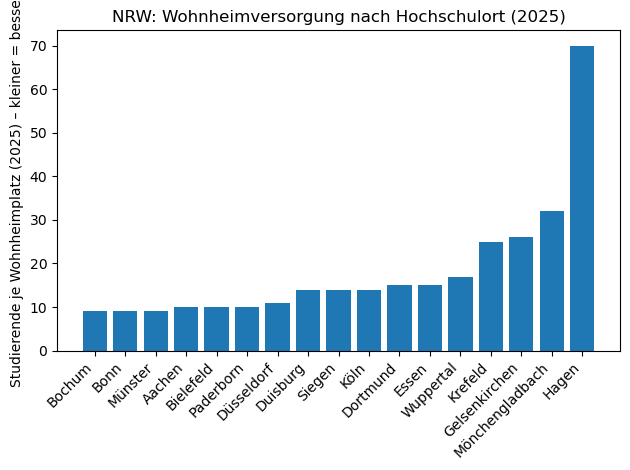

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq_s1_wohnheimversorgung_nrw_2025.png'))

In [16]:
plt.figure()
plt.bar(df_s1["hochschulort"], df_s1["studierende_je_wohnheimplatz_2025"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Studierende je Wohnheimplatz (2025) – kleiner = besser")
plt.title("NRW: Wohnheimversorgung nach Hochschulort (2025)")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq_s1_wohnheimversorgung_nrw_2025.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


**Kurzinterpretation (RQ-S1):**  
Die Wohnheimversorgung unterscheidet sich zwischen den NRW-Hochschulorten deutlich.  
Städte mit den niedrigsten „Studierende je Wohnheimplatz“-Werten sind am besten versorgt, während Städte mit hohen Werten vergleichsweise wenig Wohnheimplätze pro Studierende anbieten.


## RQ-S2: Zusammenhang Studierendenzahl und Wohnheimversorgung

Wir prüfen, ob die Größe eines Hochschulortes (Anzahl Studierende) mit der Versorgung zusammenhängt.
Dazu nutzen wir **Spearman-Korrelation**, weil die Verteilungen oft nicht normalverteilt sind.


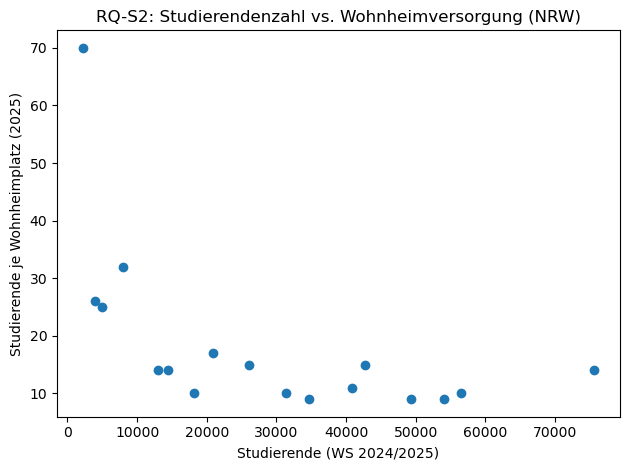

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq_s2_studierende_vs_wohnheimversorgung.png'))

In [17]:
plt.figure()
plt.scatter(
    df_nrw["studierende_ws_2024_2025"],
    df_nrw["studierende_je_wohnheimplatz_2025"]
)
plt.xlabel("Studierende (WS 2024/2025)")
plt.ylabel("Studierende je Wohnheimplatz (2025)")
plt.title("RQ-S2: Studierendenzahl vs. Wohnheimversorgung (NRW)")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq_s2_studierende_vs_wohnheimversorgung.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


In [7]:
x = df_nrw["studierende_ws_2024_2025"]
y = df_nrw["studierende_je_wohnheimplatz_2025"]

rho, p = spearmanr(x, y, nan_policy="omit")
rho, p


(-0.7066317984089711, 0.0015177924134718852)

**Kurzinterpretation (RQ-S2):**  
Die Spearman-Korrelation beschreibt, ob größere Hochschulorte tendenziell besser oder schlechter versorgt sind.  
- ρ nahe 0 → kein klarer monotone Zusammenhang  
- ρ > 0 → mehr Studierende = tendenziell mehr Studierende je Platz (schlechter versorgt)  
- ρ < 0 → mehr Studierende = tendenziell weniger Studierende je Platz (besser versorgt)

Der p-Wert zeigt, ob der Zusammenhang statistisch auffällig ist.


## Ergebnis Explore

- RQ-S1: Rangliste + Plot der NRW-Hochschulorte nach Wohnheimversorgung
- RQ-S2: Scatterplot + Spearman-Korrelation (Studierende vs. Versorgung)

